# Setup & Libraries

In [25]:
# This Magic Command activates automatic reload of imported modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
import sys
import os
import numpy as np
import autograd.numpy as anp
from autograd import grad
import networkx as nx
import matplotlib.pyplot as plt

# Adds the project folder to Python's search path
sys.path.append(os.path.abspath(os.path.join('..')))

from src.utils import test_graph, GCN_normalization, add_self_loops
from src.models import GCNModel, GATModel

# Initializing Test Graph

In [27]:
# Load fictitious graph
X, A, y = test_graph()

print(f"Node Feature Matrix X: (Shape: {X.shape}):\n{X}\n")
print(f"Adjacency Matrix A: (Shape: {A.shape}):\n{A}\n")
print(f"Target Matrix y: (Shape: {y.shape}):\n{y}\n")

Node Feature Matrix X: (Shape: (4, 3)):
[[1. 0. 1.]
 [2. 0. 1.]
 [0. 0. 2.]
 [1. 1. 0.]]

Adjacency Matrix A: (Shape: (4, 4)):
[[0. 1. 0. 0.]
 [1. 0. 1. 1.]
 [0. 1. 0. 1.]
 [0. 1. 1. 0.]]

Target Matrix y: (Shape: (4, 2)):
[[1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]]



In [28]:
# Saving the data into the .npz file at the data folder
data_path = os.path.join("..", "data", "dataset.npz")
np.savez(data_path, X=X, A=A, y=y)

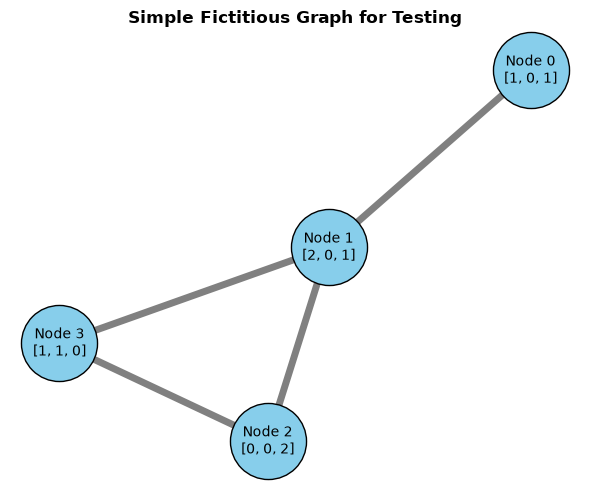

In [29]:
# Visualizing the graph with NetworkX

# Instantiate NetworkX's Graph Object
G = nx.Graph()

# Add the edges based on A
# Because A represents an undirected graph, we only iterate through the upper triangle
num_nodes = A.shape[0]
for i in range(num_nodes):
    for j in range(i + 1, num_nodes):
        if A[i, j] == 1:
            G.add_edge(i, j)

# Defines the layout
pos = nx.spring_layout(G, seed=42)

# Add the labels based on the node features
labels = {}
for i in range(num_nodes):
    features_str = f"Node {i}\n{X[i].astype(int).tolist()}"
    labels[i] = features_str

# Plot
plt.figure(figsize=(6, 5))
nx.draw_networkx_nodes(G, pos, node_color="skyblue", node_size=3000, edgecolors="black")
nx.draw_networkx_edges(G, pos, width=5, edge_color="gray")
nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_family="sans-serif")

plt.title("Simple Fictitious Graph for Testing", fontsize=12, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

# Cross Entropy Loss Function Definition 

In [30]:
def loss_fn(weights, model, A_adj, X, y):
    """
    Calculates the Cross-Entropy Loss in a pure functional way to ensure
    perfect gradient tracking by Autograd.

    Args:
        weights: Dictionary of current parameters {"W1": ..., "b1"/"a1": ..., "W2": ..., "b2"/"a2": ...}
        model: GNN Model instance (e.g., GCNModel or GATModel)
        A_adj: Correspondent Adjacency Matrix
        X: Node Feature Matrix
        y: Target matrix
    Return:
        loss: Scalar value representing the mean Cross-Entropy error
    """
    # Dynamic Injection of weights (Works for W, b, a, etc)
    for key, val in weights.items():
        # Extracts parameter name (e.g.: 'W', 'b', 'a') and the layer index (e.g.: '1', '2')
        param_name = key[:-1] 
        layer_idx = key[-1]   
        
        # Access the corresponding layer (e.g.: model.layer1)
        layer = getattr(model, f"layer{layer_idx}")
        
        # Injects the gradient/weight updated value into the proper attribute at the layer
        setattr(layer, param_name, val)

    # Forward Pass utilizing Autograd module
    y_pred = model.forward(A_adj, X, np_module=anp)
    
    # Loss Calculation (Cross-Entropy)
    eps = 1e-15
    y_pred = anp.clip(y_pred, eps, 1.0 - eps)
    loss = -anp.sum(y * anp.log(y_pred)) / y.shape[0]
    
    return loss

# GCN Model Application

## Model Setup

In [31]:
A_hat = GCN_normalization(A)

# Defining the seed for weight reproducibility
np.random.seed(42)

n_in = X.shape[1] # 3
n_hidden = 4
n_out = 2 # Simulating binary classification

# Instantiating the 2-layer GCN model
model = GCNModel(n_in=n_in, n_hidden=n_hidden, n_out=n_out)

# Initial weights and biases for Autograd tracking
weights = {
    "W1": model.layer1.W.copy(),
    'b1': model.layer1.b.copy(),
    "W2": model.layer2.W.copy(),
    'b2': model.layer2.b.copy()
}

# Define the function that automatically calculates the Loss gradients w.r.t. weights
loss_grad_fn = grad(loss_fn, argnum=0)

# Training Hyperparameters
learning_rate = 0.05
epochs = 1500

## Training

In [32]:
loss_history = []

for epoch in range(epochs):
    # Current Loss
    current_loss = loss_fn(weights, model, A_hat, X, y)
    loss_history.append(current_loss)

    # Gradients using Autograd
    gradients = loss_grad_fn(weights, model, A_hat, X, y)

    # Updating parameters
    weights["W1"] -= learning_rate * gradients["W1"]
    weights['b1'] -= learning_rate * gradients['b1']
    weights["W2"] -= learning_rate * gradients["W2"]
    weights['b2'] -= learning_rate * gradients['b2']

    if (epoch + 1) % 150 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {current_loss:.6f}")

# Updating the final weights and biases after optimization
model.layer1.W = weights["W1"]
model.layer1.b = weights['b1']
model.layer2.W = weights["W2"]
model.layer2.b = weights['b2']

Epoch 01/1500 | Loss: 0.710128
Epoch 150/1500 | Loss: 0.662430
Epoch 300/1500 | Loss: 0.600266
Epoch 450/1500 | Loss: 0.491679
Epoch 600/1500 | Loss: 0.356789
Epoch 750/1500 | Loss: 0.245427
Epoch 900/1500 | Loss: 0.171604
Epoch 1050/1500 | Loss: 0.124569
Epoch 1200/1500 | Loss: 0.093894
Epoch 1350/1500 | Loss: 0.073175
Epoch 1500/1500 | Loss: 0.058685


## Model Evaluation

>> GCN From Scratch Results <<
Node 0: Class 0 = 0.9978 | Class 1 = 0.0022
Node 1: Class 0 = 0.9002 | Class 1 = 0.0998
Node 2: Class 0 = 0.0616 | Class 1 = 0.9384
Node 3: Class 0 = 0.0616 | Class 1 = 0.9384


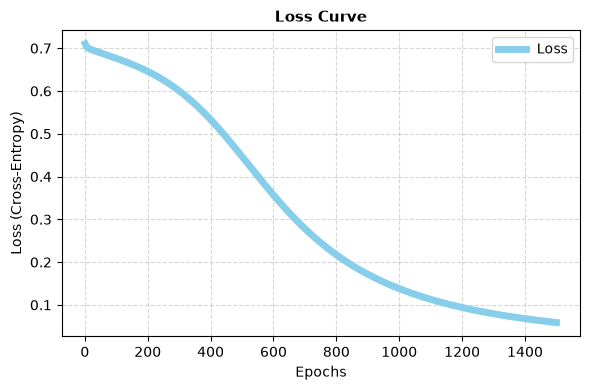

In [33]:
# Forward Propagation
y_pred = model.forward(A_hat, X)

# Results
print(">> GCN From Scratch Results <<")
for node_idx, probs in enumerate(y_pred):
    print(f"Node {node_idx}: Class 0 = {probs[0]:.4f} | Class 1 = {probs[1]:.4f}")

# Plot Loss History
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), loss_history, linewidth=5, color='skyblue', label='Loss')
plt.title("Loss Curve", fontsize=11, fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("Loss (Cross-Entropy)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

The results were coherent and satisfactory:

- The classification of each node was perfectly accurate regarding its ground truth.

- The fact that nodes 2 and 3 present the same outputs shows that the model understood the symmetry of these nodes for message passing (when the self-loops were added, these nodes show the same configuration in the Adjacency Matrix, i.e. A_til[2] = [0, 1, 1, 1] == A_til[3]).

- The Loss Curve shows a typical downward trend and convergence throughout the epochs, indicating stable learning without clear signs of overfitting or oversmoothing.

To conclude, the final results validate the GCN model implementation from scratch.

# GAT Model Application

## Model Setup

In [34]:
A_til = add_self_loops(A)

# Defining the seed for weight reproducibility
np.random.seed(42)

n_in = X.shape[1] # 3
n_hidden = 4
n_out = 2 # Simulating binary classification

leaky_relu_slope = 0.2

# Instantiating the 2-layer GAT model
model = GATModel(n_in=n_in, n_hidden=n_hidden, n_out=n_out, leaky_relu_slope=leaky_relu_slope)

# Initial weights and attention vectors for Autograd tracking
weights = {
    "W1": model.layer1.W.copy(),
    'a1': model.layer1.a.copy(),
    "W2": model.layer2.W.copy(),
    'a2': model.layer2.a.copy()
}

# Define the function that automatically calculates the Loss gradients w.r.t. weights
loss_grad_fn = grad(loss_fn, argnum=0)

# Training Hyperparameters
learning_rate = 0.05
epochs = 1500

## Training

In [35]:
loss_history = []

for epoch in range(epochs):
    # Current Loss
    current_loss = loss_fn(weights, model, A_til, X, y)
    loss_history.append(current_loss)

    # Gradients using Autograd
    gradients = loss_grad_fn(weights, model, A_til, X, y)

    # Updating parameters
    weights["W1"] -= learning_rate * gradients["W1"]
    weights['a1'] -= learning_rate * gradients['a1']
    weights["W2"] -= learning_rate * gradients["W2"]
    weights['a2'] -= learning_rate * gradients['a2']

    if (epoch + 1) % 150 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {current_loss:.6f}")

# Updating the final weights and attention vectors after optimization
model.layer1.W = weights["W1"]
model.layer1.a = weights['a1']
model.layer2.W = weights["W2"]
model.layer2.a = weights['a2']

Epoch 01/1500 | Loss: 0.790808
Epoch 150/1500 | Loss: 0.438836
Epoch 300/1500 | Loss: 0.024914
Epoch 450/1500 | Loss: 0.009641
Epoch 600/1500 | Loss: 0.005801
Epoch 750/1500 | Loss: 0.004092
Epoch 900/1500 | Loss: 0.003136
Epoch 1050/1500 | Loss: 0.002529
Epoch 1200/1500 | Loss: 0.002110
Epoch 1350/1500 | Loss: 0.001806
Epoch 1500/1500 | Loss: 0.001574


## Model Evaluation

>> GAT From Scratch Results <<
Node 0: Class 0 = 0.9992 | Class 1 = 0.0008
Node 1: Class 0 = 0.9990 | Class 1 = 0.0010
Node 2: Class 0 = 0.0022 | Class 1 = 0.9978
Node 3: Class 0 = 0.0022 | Class 1 = 0.9978


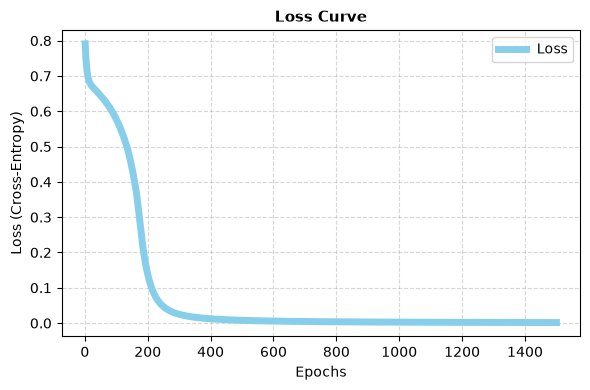

In [36]:
# Forward Propagation
y_pred = model.forward(A_til, X)

# Results
print(">> GAT From Scratch Results <<")
for node_idx, probs in enumerate(y_pred):
    print(f"Node {node_idx}: Class 0 = {probs[0]:.4f} | Class 1 = {probs[1]:.4f}")

# Plot Loss History
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), loss_history, linewidth=5, color='skyblue', label='Loss')
plt.title("Loss Curve", fontsize=11, fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("Loss (Cross-Entropy)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

The results were once again coherent and highly satisfactory:

- As observed previously, the classification of each node achieved perfect accuracy regarding its ground truth.

- The model successfully preserved the topological symmetry of nodes 2 and 3, yielding identical predicted probabilities. This confirms that the attention mechanism correctly distributed consistent weights for identical neighborhood configurations.

- The Loss Curve displays a steep and accelerated downward trend, converging much faster than the static approach. This rapid convergence highlights the efficiency of the dynamic routing, stabilizing quickly without signs of overfitting or instability.

To conclude, the final results validate the GAT model implementation from scratch, successfully demonstrating the practical advantages of the attention mechanism over static aggregation.